# 🛢️ Sprint 1: Adquisición y Validación de Datos
**Proyecto:** Análisis de la Dinámica Productiva en la Cuenca Cuyana  
**Objetivo de este notebook:** Cargar los datos crudos, explorar la estructura, aislar los registros de la Cuenca Cuyana (Mendoza), tratar valores faltantes y generar las primeras variables derivadas (como la fecha de primera producción).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Configuración visual básica
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# Definimos la ruta donde tu compañero guardó el archivo procesado de la auditoría
RUTA_DATOS = "../data/processed/produccion_pozos_cuenca_cuyana_2021_2026.csv"

## 1. Explorar columnas y diccionario de datos
Cargamos el dataset histórico consolidado y revisamos sus tipos de datos.

In [3]:
# Carga de datos
df = pd.read_csv(RUTA_DATOS)

# Exploración inicial
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
display(df.info())
display(df.describe().T)

Filas: 246240 | Columnas: 38
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246240 entries, 0 to 246239
Data columns (total 38 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               246240 non-null  object 
 1   anio                    246240 non-null  int64  
 2   mes                     246240 non-null  int64  
 3   idpozo                  246240 non-null  int64  
 4   prod_pet                246240 non-null  float64
 5   prod_gas                246240 non-null  float64
 6   prod_agua               246240 non-null  float64
 7   iny_agua                246240 non-null  float64
 8   iny_gas                 246240 non-null  float64
 9   iny_co2                 246240 non-null  float64
 10  iny_otro                246240 non-null  float64
 11  tef                     246240 non-null  float64
 12  vida_util               15525 non-null   float64
 13  tipoextraccion          246240 non-null  obje

None

,count,mean,std,min,25%,50%,75%,max
anio,246240.0,2023.317495,1.623234,2021.0,2022.0,2023.0,2025.00,2026.00
mes,246240.0,6.241309,3.415961,1.0,3.0,6.0,9.00,12.00
idpozo,246240.0,119576.223501,27702.114278,596.0,122646.0,123578.0,124519.00,167276.00
prod_pet,246240.0,22.100513,59.121913,0.0,0.0,0.0,0.00,1245.60
prod_gas,246240.0,1.042237,3.966390,0.0,0.0,0.0,0.00,657.22
prod_agua,246240.0,710.086137,2401.554691,0.0,0.0,0.0,0.00,28221.28
iny_agua,246240.0,705.662538,5571.317121,0.0,0.0,0.0,0.00,218837.80
iny_gas,246240.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.00
iny_co2,246240.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.00
iny_otro,246240.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.00


## 2. Filtrar e identificar registros (Foco en Mendoza)
Validamos que estamos trabajando con la Cuenca Cuyana y limitamos el alcance a la provincia de Mendoza para nuestro análisis.


In [4]:
# Validamos las cuencas y provincias disponibles
print("Distribución por Cuenca:\n", df['cuenca'].value_counts())
print("\nDistribución por Provincia:\n", df['provincia'].value_counts())

# Filtramos estrictamente Mendoza si hay pozos de otras provincias en la cuenca
df_mendoza = df[df['provincia'] == 'Mendoza'].copy()
print(f"\nPozos únicos en Mendoza: {df_mendoza['idpozo'].nunique()}")

Distribución por Cuenca:
 cuenca
CUYANA    246240
Name: count, dtype: int64

Distribución por Provincia:
 provincia
Mendoza    246240
Name: count, dtype: int64

Pozos únicos en Mendoza: 3702


## 3. Evaluar identificador único y continuidad mensual
Verificamos que `idpozo` sea consistente y calculamos cuántos meses de datos tiene cada pozo para saber si sirven para el análisis de maduración.

In [5]:
# Check de duplicados exactos por mes y pozo
duplicados = df_mendoza.duplicated(subset=['idpozo', 'anio', 'mes']).sum()
print(f"Registros duplicados por pozo-mes: {duplicados}")

# Continuidad: ¿Cuántos meses de registro tiene cada pozo?
meses_por_pozo = df_mendoza.groupby('idpozo').size()
display(meses_por_pozo.describe())

# Clasificamos la completitud
df_mendoza['meses_registrados'] = df_mendoza.groupby('idpozo')['idpozo'].transform('count')

Registros duplicados por pozo-mes: 0


count    3702.000000
mean       66.515397
std         4.770967
min         4.000000
25%        67.000000
50%        67.000000
75%        67.000000
max        68.000000
dtype: float64

## 4. Detectar fecha de primera producción
Buscamos el primer mes cronológico en el que el pozo reportó una producción de petróleo mayor a cero.

In [6]:
# Aseguramos que la fecha sea formato datetime
df_mendoza['fecha_data'] = pd.to_datetime(df_mendoza['fecha_data'])

# Filtramos solo los meses donde hubo producción real
df_prod_activa = df_mendoza[df_mendoza['prod_pet'] > 0]

# Buscamos la fecha mínima por pozo
fecha_primera_prod = df_prod_activa.groupby('idpozo')['fecha_data'].min().reset_index()
fecha_primera_prod.rename(columns={'fecha_data': 'fecha_primera_produccion'}, inplace=True)

# Unimos esta nueva variable al dataset original
df_mendoza = df_mendoza.merge(fecha_primera_prod, on='idpozo', how='left')
df_mendoza[['idpozo', 'fecha_data', 'prod_pet', 'fecha_primera_produccion']].head()

,idpozo,fecha_data,prod_pet,fecha_primera_produccion
0,162019,2021-01-31,0.00,NaT
1,160838,2021-01-31,91.23,2021-01-31
2,160267,2021-01-31,32.58,2021-01-31
3,160265,2021-01-31,843.53,2021-01-31
4,160142,2021-01-31,37.81,2021-01-31


## 5. Clasificación y Separación de Recursos
Analizamos la proporción de Convencional vs No Convencional y definimos columnas de interés.

In [7]:
# Proporción de tipo de recurso
print(df_mendoza['tipo_de_recurso'].value_counts(normalize=True) * 100)

# Para este proyecto, nos centraremos principalmente en:
columnas_clave = [
    'idpozo', 'fecha_data', 'anio', 'mes', 'areayacimiento', 
    'prod_pet', 'prod_gas', 'prod_agua', 'tipo_de_recurso', 
    'fecha_primera_produccion'
]
df_limpio = df_mendoza[columnas_clave].copy()

tipo_de_recurso
CONVENCIONAL    100.0
Name: proportion, dtype: float64


## 6. Reporte de Faltantes y Outliers
Evaluamos la calidad final de nuestro dataset reducido.

In [8]:
# Cuantificar nulos
print("Reporte de Valores Nulos:\n", df_limpio.isnull().sum())

# Detectar valores imposibles (ej. producción negativa)
prod_negativa = df_limpio[df_limpio['prod_pet'] < 0]
print(f"\nRegistros con producción de petróleo negativa: {len(prod_negativa)}")

# Limpieza básica de inconsistencias si existieran
df_limpio['prod_pet'] = df_limpio['prod_pet'].clip(lower=0) 
df_limpio['prod_gas'] = df_limpio['prod_gas'].clip(lower=0)

Reporte de Valores Nulos:
 idpozo                           0
fecha_data                       0
anio                             0
mes                              0
areayacimiento                   0
prod_pet                         0
prod_gas                         0
prod_agua                        0
tipo_de_recurso                  0
fecha_primera_produccion    172722
dtype: int64

Registros con producción de petróleo negativa: 0


## 7. Validación del criterio de filtrado geográfico (Cuenca vs. Provincia)

Qué se hace acá: se compara el filtro por cuenca == 'CUYANA' (el definido como universo del proyecto en el contexto maestro) contra el filtro por provincia == 'Mendoza' (usado en la exploración inicial de Sprint 1), para confirmar si ambos producen el mismo subconjunto de datos antes de construir las tablas de análisis. Esto evita arrastrar una inconsistencia de alcance geográfico a los resultados finales.

In [9]:
import pandas as pd

df = pd.read_csv("../data/processed/produccion_pozos_cuenca_cuyana_2021_2026.csv")

pozos_cuenca = df[df['cuenca'] == 'CUYANA']['idpozo'].nunique()
pozos_mendoza = df[df['provincia'] == 'Mendoza']['idpozo'].nunique()
pozos_interseccion = df[(df['cuenca'] == 'CUYANA') & (df['provincia'] == 'Mendoza')]['idpozo'].nunique()

print(f"Pozos por cuenca == CUYANA: {pozos_cuenca}")
print(f"Pozos por provincia == Mendoza: {pozos_mendoza}")
print(f"Pozos que cumplen ambas condiciones: {pozos_interseccion}")

# ¿Hay pozos de Cuyana en otras provincias (San Juan, La Rioja)?
print(df[df['cuenca'] == 'CUYANA']['provincia'].value_counts())

# ¿Hay pozos en Mendoza que NO son de la Cuenca Cuyana?
print(df[df['provincia'] == 'Mendoza']['cuenca'].value_counts())

Pozos por cuenca == CUYANA: 3702
Pozos por provincia == Mendoza: 3702
Pozos que cumplen ambas condiciones: 3702
provincia
Mendoza    246240
Name: count, dtype: int64
cuenca
CUYANA    246240
Name: count, dtype: int64


Se validó que el filtro por cuenca == 'CUYANA' y por provincia == 'Mendoza' producen exactamente el mismo conjunto de 3.702 pozos únicos, sin registros exclusivos de ninguno de los dos criterios. Esto confirma que, para el período y dataset analizados, toda la Cuenca Cuyana corresponde a la provincia de Mendoza y viceversa. Se adopta cuenca == 'CUYANA' como criterio de filtrado oficial del proyecto, por ser el que coincide con la definición de universo establecida en el contexto maestro, aunque el resultado sería idéntico usando provincia == 'Mendoza'.

In [10]:
# Filtro oficial del proyecto (equivalente al de provincia, pero alineado a la definición del contexto maestro)
df_cuyana = df[df['cuenca'] == 'CUYANA'].copy()
print(f"Pozos únicos en Cuyana: {df_cuyana['idpozo'].nunique()}")

Pozos únicos en Cuyana: 3702


## 8: Tabla Macro (Cuenca Cuyana / tiempo)

Se agrega el dataset a nivel año-mes para obtener la evolución histórica de producción total, cantidad de pozos activos y pozos nuevos por período — la base para el análisis de la Línea 1 (resiliencia/evolución productiva).

In [11]:
df_cuyana['fecha_data'] = pd.to_datetime(df_cuyana['fecha_data'])

df_macro = (
    df_cuyana
    .groupby(["anio", "mes"])
    .agg(
        produccion_petroleo=("prod_pet", "sum"),
        produccion_gas=("prod_gas", "sum"),
        pozos_activos=("idpozo", "nunique")
    )
    .reset_index()
)

# Pozos nuevos por mes: primera aparición de cada pozo en el histórico
primer_registro = df_cuyana.groupby("idpozo")[["anio", "mes"]].min().reset_index()
pozos_nuevos = primer_registro.groupby(["anio", "mes"]).size().reset_index(name="pozos_nuevos")

df_macro = df_macro.merge(pozos_nuevos, on=["anio", "mes"], how="left")
df_macro["pozos_nuevos"] = df_macro["pozos_nuevos"].fillna(0).astype(int)

df_macro.to_csv("../data/processed/tabla_macro_cuyana.csv", index=False)
df_macro.head()

,anio,mes,produccion_petroleo,produccion_gas,pozos_activos,pozos_nuevos
0,2021,1,96999.971498,3998.416434,3660,3673
1,2021,2,83233.670986,3505.785425,3577,0
2,2021,3,93288.301759,3937.385785,3664,0
3,2021,4,94448.064233,3922.123445,3664,0
4,2021,5,98521.937118,4081.578993,3667,0


## 9. Tabla Micro (pozo / mes)

Qué se hace acá: se confirma que el dataset filtrado ya tiene granularidad de una fila por pozo-mes, y se seleccionan las columnas relevantes con su metadata (yacimiento, recurso), dejando la base lista para feature engineering y el análisis de ramp-up de la Línea 2.

In [12]:
duplicados = df_cuyana.duplicated(subset=["idpozo", "anio", "mes"]).sum()
print("Duplicados pozo-mes:", duplicados)  # debería dar 0

columnas_clave = [
    'idpozo', 'fecha_data', 'anio', 'mes', 'areayacimiento',
    'prod_pet', 'prod_gas', 'prod_agua', 'tipo_de_recurso'
]
df_micro = df_cuyana[columnas_clave].copy()

df_micro.to_csv("../data/processed/tabla_micro_cuyana.csv", index=False)
df_micro.head()

Duplicados pozo-mes: 0


,idpozo,fecha_data,anio,mes,areayacimiento,prod_pet,prod_gas,prod_agua,tipo_de_recurso
0,162019,2021-01-31,2021,1,UGARTECHE,0.00,0.00,235.47,CONVENCIONAL
1,160838,2021-01-31,2021,1,UGARTECHE,91.23,3.23,10.23,CONVENCIONAL
2,160267,2021-01-31,2021,1,UGARTECHE,32.58,1.20,83.11,CONVENCIONAL
3,160265,2021-01-31,2021,1,MESA VERDE,843.53,30.47,313.61,CONVENCIONAL
4,160142,2021-01-31,2021,1,LA VENTANA CENTRAL,37.81,2.10,189.83,CONVENCIONAL


## 13. EDA — Distribuciones y variables categóricas

En esta sección se analiza la distribución de los pozos de la Cuenca Cuyana según variables categóricas relevantes, como yacimiento, operador, provincia y tipo de recurso.

El objetivo es identificar qué categorías concentran la mayor cantidad de pozos y explorar si existen diferencias en los niveles de producción entre ellas.

In [13]:
# Columnas categóricas disponibles
columnas_categoricas = [
    col for col in df_cuyana.columns
    if any(palabra in col.lower()
           for palabra in ['oper', 'empresa', 'prov', 'yacimiento', 'recurso'])
]

columnas_categoricas

['idempresa',
 'empresa',
 'idareayacimiento',
 'areayacimiento',
 'provincia',
 'tipo_de_recurso',
 'sub_tipo_recurso']

In [14]:
# Un registro por pozo para analizar distribuciones categóricas
df_pozos = (
    df_cuyana
    .sort_values("fecha_data")
    .drop_duplicates(subset="idpozo")
    .copy()
)

print("Pozos únicos:", df_pozos["idpozo"].nunique())
print("Filas en df_pozos:", len(df_pozos))

Pozos únicos: 3702
Filas en df_pozos: 3702


### 13.1 Distribución de pozos por yacimiento

areayacimiento
BARRANCAS                    718
VIZCACHERAS                  495
VACAS MUERTAS                463
PUNTA DE LAS BARDAS          365
UGARTECHE                    235
PIEDRAS COLORADAS            186
ESTRUCTURA CRUZ DE PIEDRA    181
LUNLUNTA-CARRIZAL            127
LA VENTANA                   113
CACHEUTA                     113
CHAÑARES HERRADOS             84
CAÑADA DURA                   83
TUPUNGATO                     64
RIO TUNUYAN                   61
RIO VIEJAS                    52
Name: count, dtype: int64

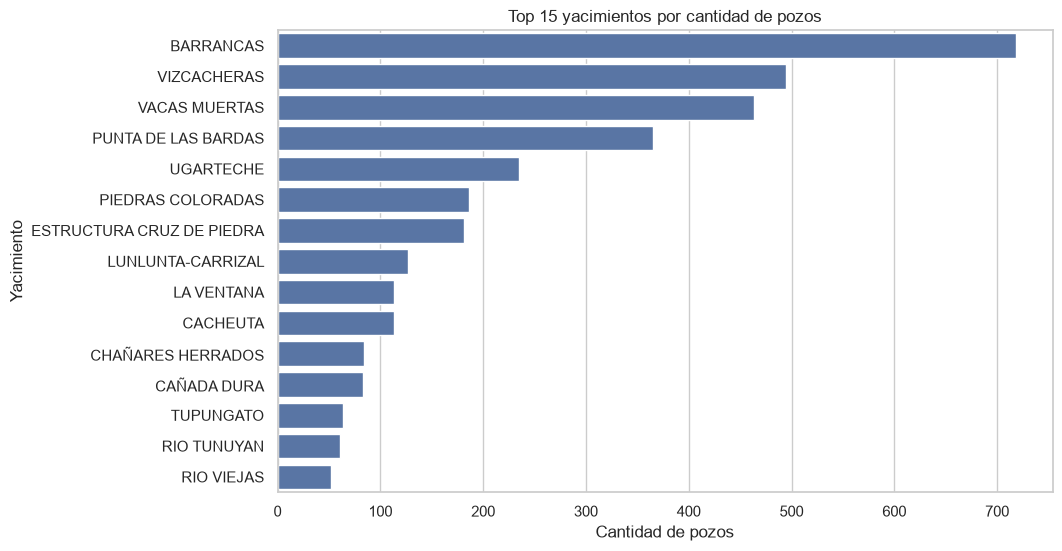

In [15]:
dist_yacimiento = (
    df_pozos["areayacimiento"]
    .value_counts()
    .head(15)
)

display(dist_yacimiento)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=dist_yacimiento.values,
    y=dist_yacimiento.index
)

plt.title("Top 15 yacimientos por cantidad de pozos")
plt.xlabel("Cantidad de pozos")
plt.ylabel("Yacimiento")
plt.show()

### 13.2 Distribución de pozos por operador

empresa
YPF S.A.                                              3114
SINOPEC ARGENTINA EXPLORATION AND PRODUCTION, INC.     297
PETROLERA EL TREBOL S.A.                               164
CHAÑARES ENERGIA S.A.                                   83
Petrolera Aconcagua Energia S.A.                        30
PETROLEOS SUDAMERICANOS S.A.                            13
TANGO ENERGY ARGENTINA S.A.                              1
Name: count, dtype: int64

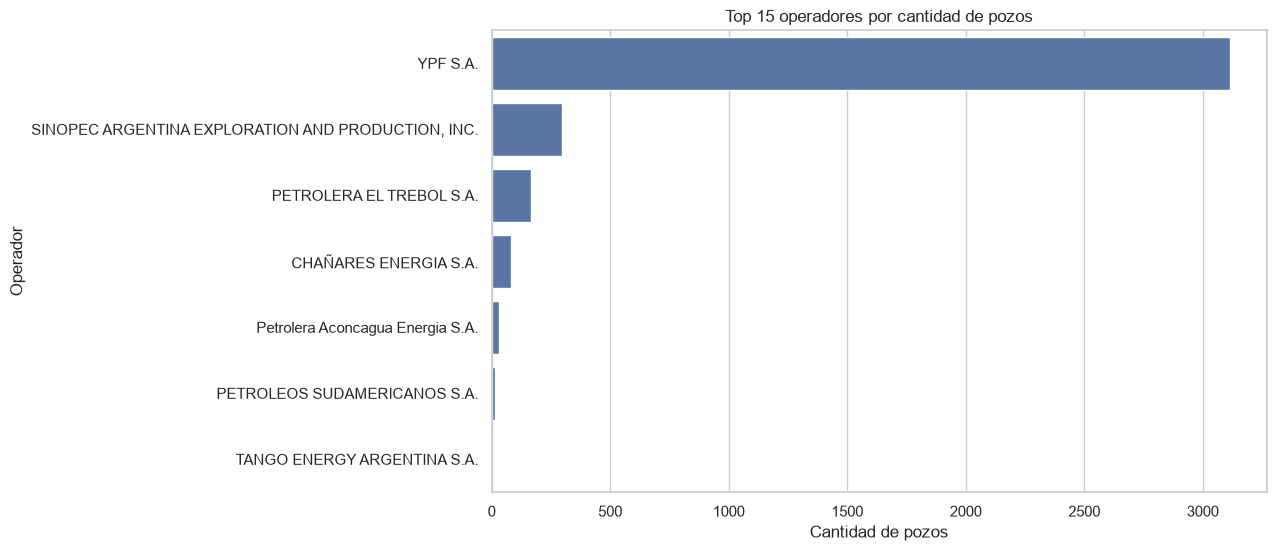

In [16]:
dist_operador = (
    df_pozos["empresa"]
    .value_counts()
    .head(15)
)

display(dist_operador)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=dist_operador.values,
    y=dist_operador.index
)

plt.title("Top 15 operadores por cantidad de pozos")
plt.xlabel("Cantidad de pozos")
plt.ylabel("Operador")
plt.show()

### 13.3 Distribución de pozos por provincia

Se verifica la distribución de los pozos según provincia. Dado que el universo de análisis fue previamente filtrado a la Cuenca Cuyana y se validó su correspondencia con Mendoza en este dataset, se espera que todos los pozos pertenezcan a una única provincia.

In [19]:
# Cantidad de pozos únicos por provincia
dist_provincia = df_pozos["provincia"].value_counts()

display(dist_provincia)

provincia
Mendoza    3702
Name: count, dtype: int64

**Observación:** Los 3.702 pozos analizados pertenecen a Mendoza. Por lo tanto, la variable `provincia` no presenta variabilidad dentro del subconjunto seleccionado y no se considera necesario representarla mediante un gráfico.

### 13.4 Distribución de pozos por tipo de recurso

In [20]:
# Cantidad de pozos únicos por tipo de recurso
dist_recurso = df_pozos["tipo_de_recurso"].value_counts()

display(dist_recurso)

tipo_de_recurso
CONVENCIONAL    3702
Name: count, dtype: int64

**Observación:** Los 3.702 pozos del subconjunto están clasificados como `CONVENCIONAL`. Al no existir distintas categorías de recurso dentro de los datos analizados, esta variable no aporta capacidad de comparación en esta etapa y no se representa gráficamente.

### 13.5 Boxplots de producción por categoría

Se analiza la distribución de la producción mensual de petróleo según operador y yacimiento.

Los boxplots permiten comparar la mediana, la dispersión y la presencia de valores extremos entre categorías. En esta etapa los valores atípicos se mantienen sin modificar, ya que su identificación y tratamiento se abordará específicamente en la sección de valores faltantes y outliers.

In [24]:
cuartiles_operador = (
    df_cuyana
    .groupby("empresa")["prod_pet"]
    .agg(
        Q1=lambda x: x.quantile(0.25),
        Mediana=lambda x: x.quantile(0.50),
        Q3=lambda x: x.quantile(0.75)
    )
)

cuartiles_operador["IQR"] = (
    cuartiles_operador["Q3"] - cuartiles_operador["Q1"]
)

cuartiles_operador["Limite_inferior"] = (
    cuartiles_operador["Q1"] - 1.5 * cuartiles_operador["IQR"]
)

cuartiles_operador["Limite_superior"] = (
    cuartiles_operador["Q3"] + 1.5 * cuartiles_operador["IQR"]
)

cuartiles_operador

,Q1,Mediana,Q3,IQR,Limite_inferior,Limite_superior
empresa,,,,,,
CGC ENERGIA SAU,0.0,0.0,0.000000,0.000000,0.000000,0.000000
CHAÑARES ENERGIA S.A.,0.0,0.0,21.164875,21.164875,-31.747313,52.912188
PETROLEOS SUDAMERICANOS S.A.,0.0,0.0,0.000000,0.000000,0.000000,0.000000
PETROLERA EL TREBOL S.A.,0.0,0.0,0.000000,0.000000,0.000000,0.000000
PHOENIX GLOBAL RESOURCES S.A.,0.0,0.0,11.601370,11.601370,-17.402055,29.003425
Petrolera Aconcagua Energia S.A.,0.0,0.0,89.900000,89.900000,-134.850000,224.750000
"SINOPEC ARGENTINA EXPLORATION AND PRODUCTION, INC.",0.0,0.0,0.000000,0.000000,0.000000,0.000000
TANGO ENERGY ARGENTINA S.A.,0.0,0.0,69.440000,69.440000,-104.160000,173.600000
VENOIL S.A.,0.0,0.0,0.000000,0.000000,0.000000,0.000000


In [26]:
top_yacimientos = (
    df_pozos["areayacimiento"]
    .value_counts()
    .head(10)
    .index
)

df_top_yacimientos = df_cuyana[
    df_cuyana["areayacimiento"].isin(top_yacimientos)
].copy()

cuartiles_yacimiento = (
    df_top_yacimientos
    .groupby("areayacimiento")["prod_pet"]
    .agg(
        Q1=lambda x: x.quantile(0.25),
        Mediana=lambda x: x.quantile(0.50),
        Q3=lambda x: x.quantile(0.75)
    )
)

cuartiles_yacimiento["IQR"] = (
    cuartiles_yacimiento["Q3"] - cuartiles_yacimiento["Q1"]
)

cuartiles_yacimiento["Limite_inferior"] = (
    cuartiles_yacimiento["Q1"] - 1.5 * cuartiles_yacimiento["IQR"]
)

cuartiles_yacimiento["Limite_superior"] = (
    cuartiles_yacimiento["Q3"] + 1.5 * cuartiles_yacimiento["IQR"]
)

cuartiles_yacimiento

cuartiles_yacimiento["IQR"] = (
    cuartiles_yacimiento["Q3"] - cuartiles_yacimiento["Q1"]
)

cuartiles_yacimiento["Limite_inferior"] = (
    cuartiles_yacimiento["Q1"] - 1.5 * cuartiles_yacimiento["IQR"]
)

cuartiles_yacimiento["Limite_superior"] = (
    cuartiles_yacimiento["Q3"] + 1.5 * cuartiles_yacimiento["IQR"]
)

cuartiles_yacimiento

,Q1,Mediana,Q3,IQR,Limite_inferior,Limite_superior
areayacimiento,,,,,,
BARRANCAS,0.0,0.0,0.000000,0.000000,0.000000,0.000000
CACHEUTA,0.0,0.0,0.000000,0.000000,0.000000,0.000000
ESTRUCTURA CRUZ DE PIEDRA,0.0,0.0,52.304000,52.304000,-78.456000,130.760000
LA VENTANA,0.0,0.0,0.000000,0.000000,0.000000,0.000000
LUNLUNTA-CARRIZAL,0.0,0.0,0.000000,0.000000,0.000000,0.000000
PIEDRAS COLORADAS,0.0,0.0,30.230715,30.230715,-45.346072,75.576787
PUNTA DE LAS BARDAS,0.0,0.0,0.000000,0.000000,0.000000,0.000000
UGARTECHE,0.0,0.0,31.925000,31.925000,-47.887500,79.812500
VACAS MUERTAS,0.0,0.0,0.000000,0.000000,0.000000,0.000000


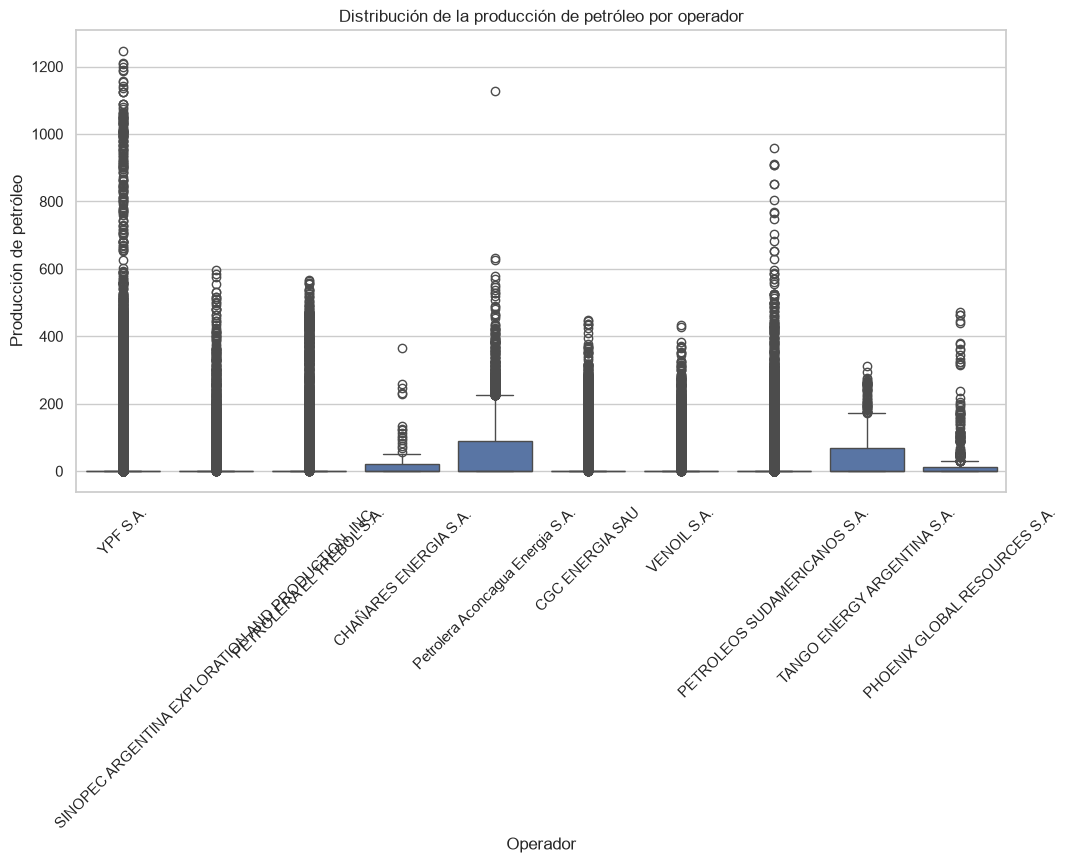

In [21]:
# Boxplot de producción de petróleo por operador

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_cuyana,
    x="empresa",
    y="prod_pet"
)

plt.title("Distribución de la producción de petróleo por operador")
plt.xlabel("Operador")
plt.ylabel("Producción de petróleo")
plt.xticks(rotation=45)
plt.show()

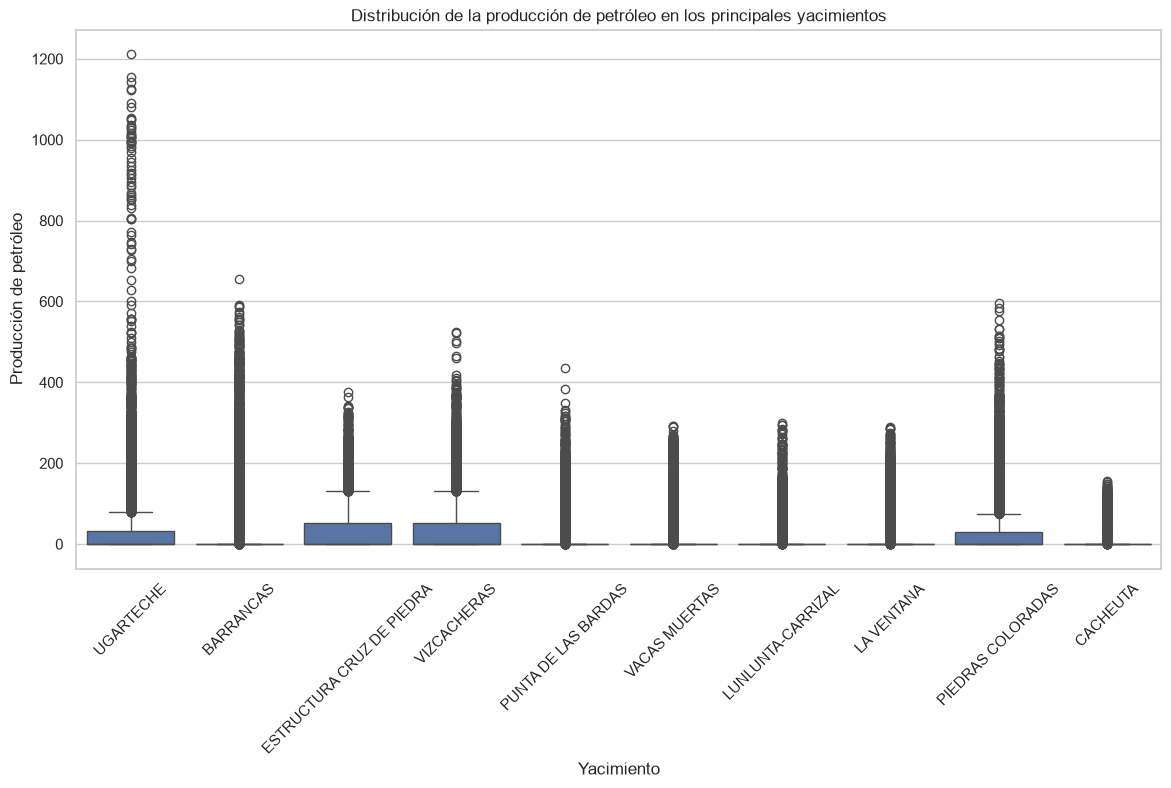

In [22]:
# Seleccionamos los 10 yacimientos con mayor cantidad de pozos

top_yacimientos = (
    df_pozos["areayacimiento"]
    .value_counts()
    .head(10)
    .index
)

df_top_yacimientos = df_cuyana[
    df_cuyana["areayacimiento"].isin(top_yacimientos)
].copy()

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_top_yacimientos,
    x="areayacimiento",
    y="prod_pet"
)

plt.title("Distribución de la producción de petróleo en los principales yacimientos")
plt.xlabel("Yacimiento")
plt.ylabel("Producción de petróleo")
plt.xticks(rotation=45)
plt.show()

### Interpretación de los cuartiles

La revisión de los cuartiles confirma que varias categorías presentan una fuerte concentración de valores de producción iguales a cero.

En distintos operadores y yacimientos se observa que Q1, la mediana y Q3 son iguales a 0. Esto indica que, para esas categorías, al menos el 75% de los registros mensuales analizados reporta producción de petróleo nula.

Por este motivo, los boxplots aparecen visualmente comprimidos en torno a cero y una gran cantidad de observaciones positivas se representan como valores atípicos respecto del rango intercuartílico.

Este comportamiento requiere un análisis específico en la sección de tratamiento de valores faltantes y outliers, ya que los valores cero pueden corresponder a períodos de inactividad y no necesariamente a errores de calidad de datos.

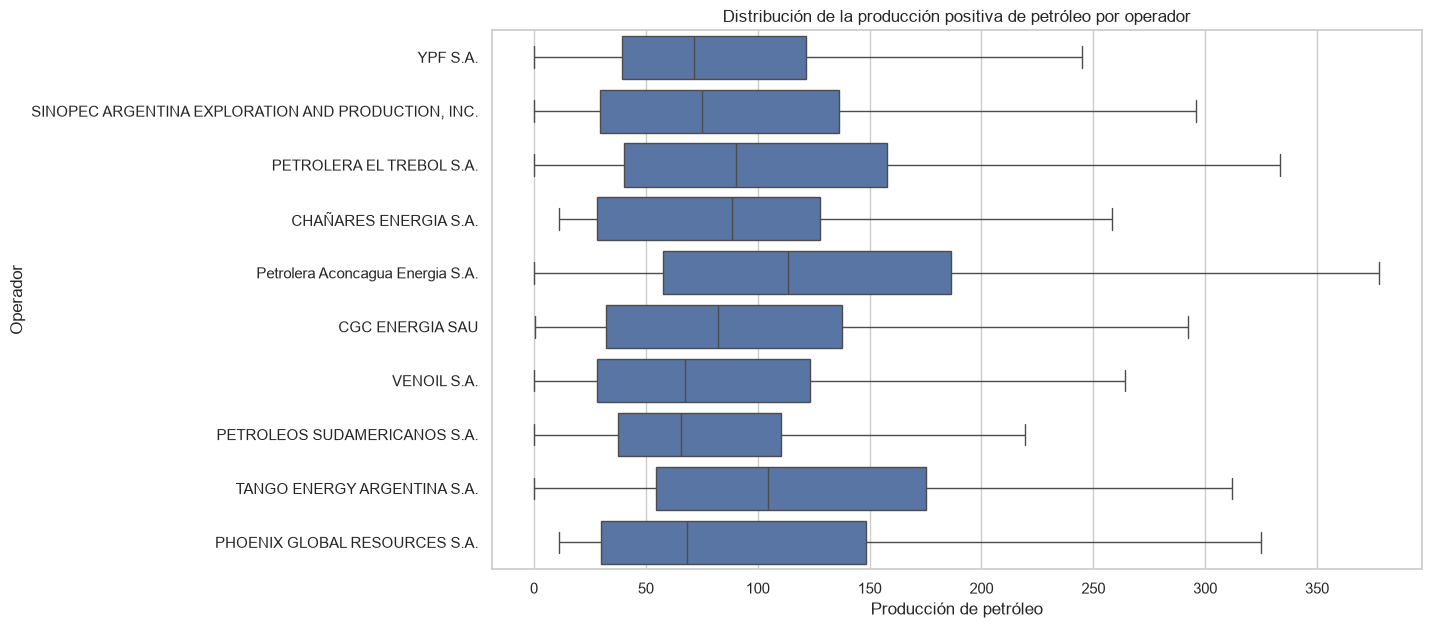

In [27]:
df_prod_positiva = df_cuyana[df_cuyana["prod_pet"] > 0].copy()

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_prod_positiva,
    y="empresa",
    x="prod_pet",
    showfliers=False
)

plt.title("Distribución de la producción positiva de petróleo por operador")
plt.xlabel("Producción de petróleo")
plt.ylabel("Operador")
plt.show()

### Boxplot considerando únicamente producción positiva

Debido a la elevada cantidad de registros con producción de petróleo igual a cero, los boxplots construidos con el dataset completo presentan varias cajas comprimidas en torno a cero.

Para facilitar la comparación entre operadores, se realiza una visualización complementaria considerando únicamente los meses con `prod_pet > 0`. Este filtro se aplica solo con fines gráficos y no implica eliminar los registros con producción cero del dataset original.

En esta visualización se observan diferencias en la mediana, el rango intercuartílico y la dispersión de la producción positiva entre operadores.

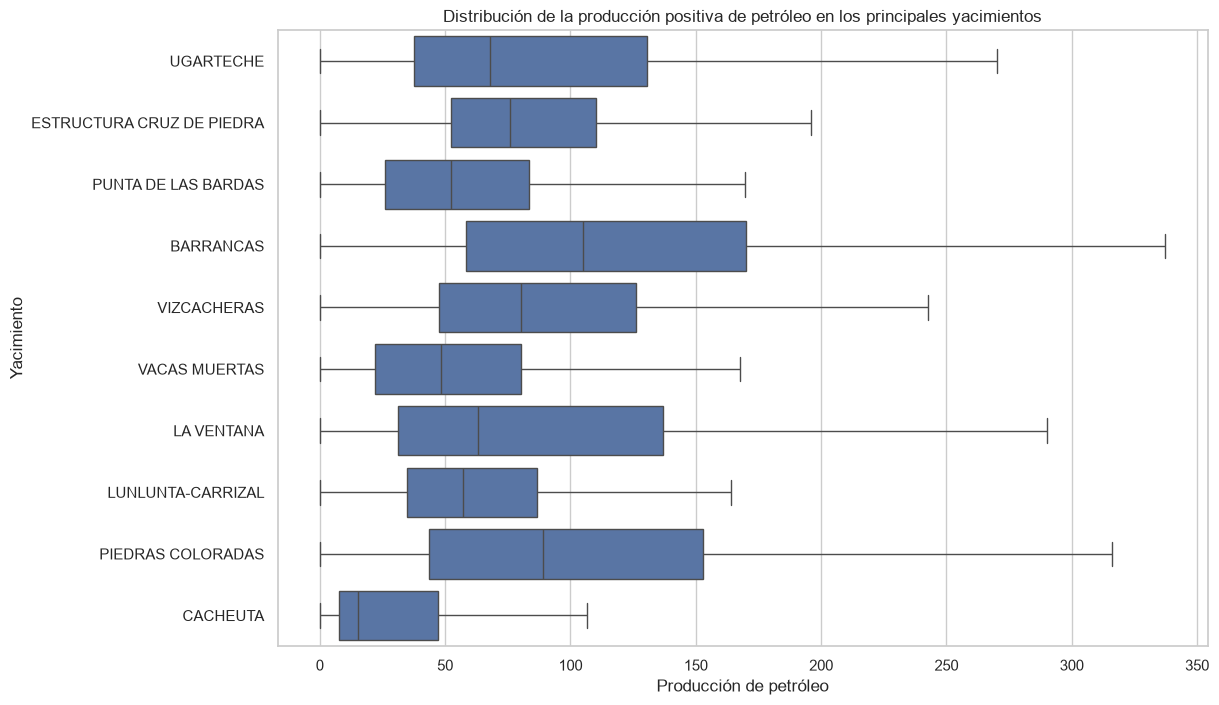

In [28]:
# Nos quedamos con los 10 yacimientos con mayor cantidad de pozos
top_yacimientos = (
    df_pozos["areayacimiento"]
    .value_counts()
    .head(10)
    .index
)

# Filtramos solo esos yacimientos y solo meses con producción positiva
df_top_yacimientos_pos = df_cuyana[
    (df_cuyana["areayacimiento"].isin(top_yacimientos)) &
    (df_cuyana["prod_pet"] > 0)
].copy()

plt.figure(figsize=(12, 8))

sns.boxplot(
    data=df_top_yacimientos_pos,
    y="areayacimiento",
    x="prod_pet",
    showfliers=False
)

plt.title("Distribución de la producción positiva de petróleo en los principales yacimientos")
plt.xlabel("Producción de petróleo")
plt.ylabel("Yacimiento")
plt.show()

### Boxplot considerando únicamente producción positiva por yacimiento

Al igual que en el caso de los operadores, la elevada cantidad de registros con producción igual a cero dificulta la interpretación del boxplot sobre el conjunto completo.

Por ello, se presenta una visualización complementaria restringida a los meses con `prod_pet > 0`, únicamente con fines exploratorios. Esto permite comparar con mayor claridad la mediana, el rango intercuartílico y la dispersión de la producción positiva entre los principales yacimientos.

Este filtro no modifica el dataset original y no implica eliminar los registros con producción cero del análisis general.

### 13.5 Relación entre yacimiento y operador

In [29]:
cruce_yacimiento_operador = pd.crosstab(
    df_pozos["areayacimiento"],
    df_pozos["empresa"]
)

cruce_yacimiento_operador

empresa,CHAÑARES ENERGIA S.A.,PETROLEOS SUDAMERICANOS S.A.,PETROLERA EL TREBOL S.A.,Petrolera Aconcagua Energia S.A.,"SINOPEC ARGENTINA EXPLORATION AND PRODUCTION, INC.",TANGO ENERGY ARGENTINA S.A.,YPF S.A.
areayacimiento,,,,,,,
AGUA ESCONDIDA,0,0,2,0,0,0,0
ATAMISQUI,0,0,35,0,0,0,1
ATAMISQUI SUR,0,0,2,0,0,0,0
BARRANCAS,0,8,0,0,0,0,710
BARRANCAS OESTE,0,0,0,0,0,0,2
BARRANCAS SUR,0,0,0,0,0,0,19
CACHEUTA,0,0,0,0,113,0,0
CARRIZAL DE ABAJO,0,0,4,0,0,0,0
CAÑADA DEL RINCON,0,0,0,0,0,0,1


### Relación entre yacimiento y operador

Como análisis complementario, se cruza la información de yacimiento y operador para observar cómo se distribuyen los pozos entre ambas variables categóricas.

El gráfico representa la cantidad de pozos únicos asociados a cada combinación yacimiento-operador. Este análisis permite identificar posibles concentraciones de determinados operadores en ciertos yacimientos, sin implicar una relación causal con los niveles de producción.

In [30]:
top_yacimientos = (
    df_pozos["areayacimiento"]
    .value_counts()
    .head(15)
    .index
)

cruce_top = pd.crosstab(
    df_pozos[
        df_pozos["areayacimiento"].isin(top_yacimientos)
    ]["areayacimiento"],
    df_pozos[
        df_pozos["areayacimiento"].isin(top_yacimientos)
    ]["empresa"]
)

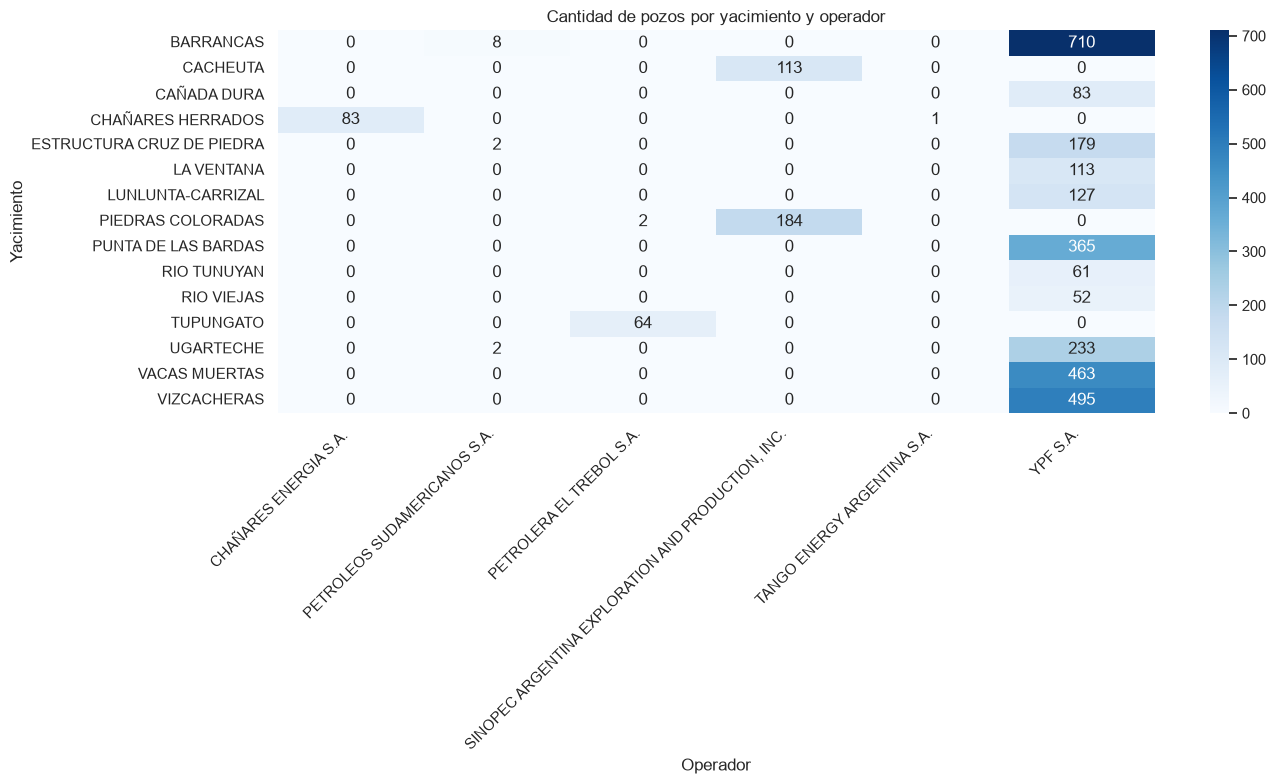

In [31]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    cruce_top,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Cantidad de pozos por yacimiento y operador")
plt.xlabel("Operador")
plt.ylabel("Yacimiento")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretación del cruce entre yacimiento y operador

El cruce entre yacimiento y operador muestra una fuerte concentración de determinados operadores en yacimientos específicos.

En varios de los principales yacimientos analizados, YPF S.A. concentra la mayor cantidad de pozos. También se observan casos en los que otros operadores presentan una participación predominante, como Sinopec en Cacheuta, Chañares Energía en Chañares Herrados y Petrolera El Trébol en Tupungato.

Este patrón sugiere que la composición por operador puede estar estrechamente vinculada con la distribución geográfica de los pozos. Por lo tanto, cualquier diferencia observada posteriormente en los niveles de producción por operador o por yacimiento debe interpretarse teniendo en cuenta esta posible concentración.

### 13.6 Estadísticas descriptivas por categoría

Se calculan estadísticas descriptivas de la producción mensual de petróleo para comparar el comportamiento entre operadores y yacimientos.

In [32]:
estadisticas_operador = (
    df_cuyana
    .groupby("empresa")["prod_pet"]
    .agg(
        registros="count",
        media="mean",
        mediana="median",
        minimo="min",
        maximo="max",
        desviacion_std="std"
    )
    .sort_values("media", ascending=False)
)

estadisticas_operador

,registros,media,mediana,minimo,maximo,desviacion_std
empresa,,,,,,
Petrolera Aconcagua Energia S.A.,6461,52.531016,0.0,0.0,1128.9100,86.514443
TANGO ENERGY ARGENTINA S.A.,509,44.339892,0.0,0.0,311.9900,76.102983
CHAÑARES ENERGIA S.A.,83,31.325171,0.0,0.0,364.8560,70.056892
PETROLERA EL TREBOL S.A.,9806,30.197489,0.0,0.0,568.0110,78.124555
PHOENIX GLOBAL RESOURCES S.A.,540,28.243402,0.0,0.0,471.1305,73.631788
CGC ENERGIA SAU,8910,23.029723,0.0,0.0,447.9829,56.522004
YPF S.A.,158913,21.891355,0.0,0.0,1245.6000,59.357086
"SINOPEC ARGENTINA EXPLORATION AND PRODUCTION, INC.",6237,21.458788,0.0,0.0,596.1193,63.094127
VENOIL S.A.,4752,20.376993,0.0,0.0,433.5700,52.868577


In [33]:
estadisticas_yacimiento = (
    df_cuyana
    .groupby("areayacimiento")["prod_pet"]
    .agg(
        registros="count",
        media="mean",
        mediana="median",
        minimo="min",
        maximo="max",
        desviacion_std="std"
    )
    .sort_values("media", ascending=False)
)

estadisticas_yacimiento.head(15)

,registros,media,mediana,minimo,maximo,desviacion_std
areayacimiento,,,,,,
EL QUEMADO,201,102.132991,0.000,0.0,568.0110,153.269608
MESA VERDE,3062,95.091004,0.000,0.0,1245.6000,195.740294
CHAÑARES HERRADOS,5565,54.249341,0.000,0.0,1128.9100,89.013395
TUPUNGATO,4288,51.501524,0.000,0.0,563.5380,104.382200
PUESTO POZO CERCADO,1224,51.204498,0.375,0.0,337.5300,75.301329
PIEDRAS COLORADAS,12462,32.695452,0.000,0.0,596.1193,69.755775
"LA VENTANA ""A""",402,32.654581,0.000,0.0,169.2400,47.297735
UGARTECHE,15616,32.623606,0.000,0.0,1211.7000,85.737981
VIZCACHERAS,33081,32.413984,0.000,0.0,523.3100,56.504908


In [34]:
estadisticas_operador_positiva = (
    df_cuyana[df_cuyana["prod_pet"] > 0]
    .groupby("empresa")["prod_pet"]
    .agg(
        registros_positivos="count",
        media="mean",
        mediana="median",
        minimo="min",
        maximo="max",
        desviacion_std="std"
    )
    .sort_values("media", ascending=False)
)

estadisticas_operador_positiva

,registros_positivos,media,mediana,minimo,maximo,desviacion_std
empresa,,,,,,
Petrolera Aconcagua Energia S.A.,2661,127.547123,113.720000,0.040000,1128.9100,92.766167
PETROLERA EL TREBOL S.A.,2388,124.001917,90.481500,0.216110,568.0110,115.905648
TANGO ENERGY ARGENTINA S.A.,190,118.784237,104.760000,0.010000,311.9900,81.715422
PHOENIX GLOBAL RESOURCES S.A.,137,111.324357,68.449660,11.189130,471.1305,110.319059
CHAÑARES ENERGIA S.A.,24,108.332885,88.438705,11.345820,364.8560,93.769875
"SINOPEC ARGENTINA EXPLORATION AND PRODUCTION, INC.",1297,103.190793,75.152610,0.000854,596.1193,103.510199
CGC ENERGIA SAU,2112,97.156645,82.462485,0.280174,447.9829,79.229620
YPF S.A.,37438,92.922190,71.735000,0.010000,1245.6000,91.405569
VENOIL S.A.,1101,87.948656,67.540000,0.010000,433.5700,78.255944


In [35]:
estadisticas_yacimiento_positiva = (
    df_cuyana[
        (df_cuyana["prod_pet"] > 0) &
        (df_cuyana["areayacimiento"].isin(top_yacimientos))
    ]
    .groupby("areayacimiento")["prod_pet"]
    .agg(
        registros_positivos="count",
        media="mean",
        mediana="median",
        minimo="min",
        maximo="max",
        desviacion_std="std"
    )
    .sort_values("media", ascending=False)
)

estadisticas_yacimiento_positiva

,registros_positivos,media,mediana,minimo,maximo,desviacion_std
areayacimiento,,,,,,
TUPUNGATO,1374,160.726735,123.621000,1.003465,563.5380,128.265046
CHAÑARES HERRADOS,2260,133.583001,117.020000,0.010000,1128.9100,94.410103
BARRANCAS,7227,124.033634,105.100000,0.001000,655.2500,91.967629
PIEDRAS COLORADAS,3678,110.780513,88.895525,0.000854,596.1193,88.528551
UGARTECHE,4864,104.738946,68.080000,0.002000,1211.7000,126.684991
VIZCACHERAS,11637,92.144624,80.190000,0.001000,523.3100,59.770380
RIO TUNUYAN,602,91.554730,82.655000,1.400000,196.8780,42.403196
ESTRUCTURA CRUZ DE PIEDRA,4011,87.871883,75.820000,0.002000,376.2000,53.080021
LA VENTANA,1533,85.007962,63.070000,0.001000,290.0100,64.235764


**Nota:** Las estadísticas sobre el dataset completo incluyen los meses con producción igual a cero. Dado que estos registros tienen un peso importante en la distribución, también se presentan estadísticas descriptivas considerando únicamente meses con producción positiva. Esta segunda tabla se utiliza como análisis complementario y no implica eliminar los registros con producción cero del dataset.

### Hallazgos de la distribución y variables categóricas

El análisis categórico muestra que la distribución de los pozos no es homogénea entre yacimientos ni operadores.

YPF S.A. concentra la mayor cantidad de pozos y registros del conjunto analizado. Sin embargo, al considerar únicamente los meses con producción positiva, otros operadores presentan medias y medianas de producción superiores, lo que indica que una mayor presencia en el dataset no implica necesariamente una mayor producción típica por registro.

En el análisis por yacimiento también se observan diferencias importantes. Algunos yacimientos presentan niveles medios y medianos de producción positiva considerablemente superiores a otros, así como distintos grados de dispersión.

La comparación entre las estadísticas del dataset completo y las calculadas únicamente sobre producción positiva confirma además una fuerte presencia de registros con producción igual a cero. Este comportamiento explica que muchas categorías presenten una mediana igual a cero en el análisis general.

El cruce entre yacimiento y operador evidencia además una concentración de determinados operadores en yacimientos específicos. Por este motivo, las diferencias observadas por operador y por yacimiento deben interpretarse teniendo en cuenta que ambas variables no son completamente independientes dentro del conjunto analizado.

Los valores extremos y la elevada dispersión observada no se modifican en esta sección. Su evaluación y eventual tratamiento se aborda específicamente en la sección siguiente de valores faltantes y outliers.

## 14. Tratamiento de valores faltantes y outliers

En esta sección se evalúa la presencia de valores faltantes, valores imposibles y observaciones extremas en las variables utilizadas para el análisis.

El objetivo no es eliminar automáticamente las observaciones atípicas, sino distinguir posibles errores de calidad de datos de valores extremos que puedan representar comportamientos reales de producción.

### 14.1 Análisis de valores faltantes

In [36]:
# Cantidad y porcentaje de valores faltantes por columna

faltantes = pd.DataFrame({
    "cantidad_nulos": df_cuyana.isnull().sum(),
    "porcentaje_nulos": df_cuyana.isnull().mean() * 100
})

faltantes = (
    faltantes[faltantes["cantidad_nulos"] > 0]
    .sort_values("porcentaje_nulos", ascending=False)
)

faltantes

,cantidad_nulos,porcentaje_nulos
sub_tipo_recurso,246240,100.000000
vida_util,230715,93.695175
observaciones,226906,92.148311
clasificacion,31079,12.621426
subclasificacion,31079,12.621426


In [37]:
columnas_eda = [
    "idpozo",
    "fecha_data",
    "empresa",
    "areayacimiento",
    "provincia",
    "tipo_de_recurso",
    "prod_pet",
    "prod_gas",
    "prod_agua"
]

faltantes_eda = pd.DataFrame({
    "cantidad_nulos": df_cuyana[columnas_eda].isnull().sum(),
    "porcentaje_nulos": df_cuyana[columnas_eda].isnull().mean() * 100
})

faltantes_eda

,cantidad_nulos,porcentaje_nulos
idpozo,0,0.0
fecha_data,0,0.0
empresa,0,0.0
areayacimiento,0,0.0
provincia,0,0.0
tipo_de_recurso,0,0.0
prod_pet,0,0.0
prod_gas,0,0.0
prod_agua,0,0.0


### Interpretación de valores faltantes

El dataset completo presenta valores faltantes en algunas variables auxiliares. En particular, `sub_tipo_recurso`, `vida_util` y `observaciones` presentan porcentajes elevados de datos ausentes, mientras que `clasificacion` y `subclasificacion` presentan faltantes en una proporción menor.

Sin embargo, las variables seleccionadas para el análisis exploratorio (`idpozo`, `fecha_data`, `empresa`, `areayacimiento`, `provincia`, `tipo_de_recurso`, `prod_pet`, `prod_gas` y `prod_agua`) no presentan valores nulos.

Por este motivo, no se requiere aplicar imputación ni exclusión de registros por valores faltantes sobre las variables utilizadas en el EDA. Las columnas auxiliares con alta proporción de nulos no se utilizarán en esta etapa del análisis.

### 14.2 Valores cero en las variables de producción

In [38]:
variables_produccion = ["prod_pet", "prod_gas", "prod_agua"]

resumen_ceros = pd.DataFrame({
    "cantidad_ceros": [
        (df_cuyana[col] == 0).sum()
        for col in variables_produccion
    ],
    "porcentaje_ceros": [
        (df_cuyana[col] == 0).mean() * 100
        for col in variables_produccion
    ]
}, index=variables_produccion)

resumen_ceros

,cantidad_ceros,porcentaje_ceros
prod_pet,188712,76.637427
prod_gas,190333,77.295728
prod_agua,188551,76.572044


In [39]:
df_cuyana[["prod_pet", "prod_gas", "prod_agua"]].dtypes

prod_pet     float64
prod_gas     float64
prod_agua    float64
dtype: object

In [40]:
for col in ["prod_pet", "prod_gas", "prod_agua"]:
    print(f"\n{col}")
    print(
        df_cuyana[col]
        .value_counts()
        .sort_index()
        .head(15)
    )


prod_pet
prod_pet
0.000000    188712
0.000854         1
0.001000         9
0.002000         7
0.005000         1
0.010000         7
0.020000         3
0.024000         1
0.030000         4
0.040000         1
0.050000         2
0.053000         1
0.060000         2
0.070000         3
0.080000         3
Name: count, dtype: int64

prod_gas
prod_gas
0.000000    190333
0.000019         1
0.000042         1
0.000280         1
0.000688         1
0.000760         1
0.000860         1
0.001000         3
0.001006         1
0.001110         1
0.001123         1
0.001130         1
0.001165         1
0.001190         2
0.001200         3
Name: count, dtype: int64

prod_agua
prod_agua
0.000000    188551
0.001000         1
0.002000         3
0.003000         1
0.004000         1
0.004544         1
0.012000         1
0.020000         5
0.030000        19
0.031000         1
0.033000         1
0.036000         3
0.040000         1
0.041000         1
0.043000         1
Name: count, dtype: int64


In [41]:
columnas_revision = [
    "idpozo",
    "fecha_data",
    "empresa",
    "areayacimiento",
    "prod_pet",
    "prod_gas",
    "prod_agua"
]

df_cuyana.loc[
    df_cuyana["prod_pet"] == 0,
    columnas_revision
].head(20)

,idpozo,fecha_data,empresa,areayacimiento,prod_pet,prod_gas,prod_agua
0,162019,2021-01-31,YPF S.A.,UGARTECHE,0.0,0.0,235.47
7,159696,2021-01-31,YPF S.A.,MESA VERDE,0.0,0.0,0.00
8,159482,2021-01-31,YPF S.A.,MESA VERDE,0.0,0.0,0.00
9,159481,2021-01-31,YPF S.A.,BARRANCAS,0.0,0.0,0.00
12,159116,2021-01-31,YPF S.A.,ESTRUCTURA CRUZ DE PIEDRA,0.0,0.0,0.00
13,158732,2021-01-31,YPF S.A.,MESA VERDE,0.0,0.0,0.00
15,158544,2021-01-31,YPF S.A.,MESA VERDE,0.0,0.0,0.00
17,158401,2021-01-31,YPF S.A.,VIZCACHERAS,0.0,0.0,0.00
18,158348,2021-01-31,YPF S.A.,VIZCACHERAS,0.0,0.0,0.00
21,129743,2021-01-31,YPF S.A.,BARRANCAS,0.0,0.0,0.00


In [42]:
df_cuyana.loc[
    (df_cuyana["prod_pet"] == 0) &
    ((df_cuyana["prod_gas"] > 0) | (df_cuyana["prod_agua"] > 0)),
    columnas_revision
].head(20)

,idpozo,fecha_data,empresa,areayacimiento,prod_pet,prod_gas,prod_agua
0,162019,2021-01-31,YPF S.A.,UGARTECHE,0.0,0.0,235.4700
3800,145061,2021-02-28,YPF S.A.,BARRANCAS,0.0,0.0,0.0700
3923,162019,2021-02-28,YPF S.A.,UGARTECHE,0.0,0.0,296.7600
6941,162019,2021-03-31,YPF S.A.,UGARTECHE,0.0,0.0,203.8100
11782,162019,2021-04-30,YPF S.A.,UGARTECHE,0.0,0.0,484.3100
12471,162019,2021-05-31,YPF S.A.,UGARTECHE,0.0,0.0,623.3700
18010,162019,2021-06-30,YPF S.A.,UGARTECHE,0.0,0.0,426.5600
20560,162019,2021-07-31,YPF S.A.,UGARTECHE,0.0,0.0,275.9400
23412,162019,2021-08-31,YPF S.A.,UGARTECHE,0.0,0.0,249.3600
25288,162019,2021-09-30,YPF S.A.,UGARTECHE,0.0,0.0,171.1400


In [43]:
# ¿Cuántas filas tienen las tres producciones simultáneamente en cero?
tres_en_cero = (
    (df_cuyana["prod_pet"] == 0) &
    (df_cuyana["prod_gas"] == 0) &
    (df_cuyana["prod_agua"] == 0)
)

print("Filas con petróleo, gas y agua en cero:", tres_en_cero.sum())
print(
    "Porcentaje:",
    round(tres_en_cero.mean() * 100, 2),
    "%"
)

Filas con petróleo, gas y agua en cero: 188517
Porcentaje: 76.56 %


In [44]:
[col for col in df_cuyana.columns
 if any(palabra in col.lower()
        for palabra in ["estado", "status", "situacion", "activo", "actividad"])]

['tipoestado']

In [45]:
df_cuyana["tipoestado"].value_counts(dropna=False)

tipoestado
Abandonado                            75936
Extracción Efectiva                   64195
A Abandonar                           19256
En Inyección Efectiva                 18502
Parado Alta Relación Agua/Petróleo    15451
En Estudio                            14521
En Reserva para Recup. Sec./Asist.    13054
En Espera de Reparación               11720
Parado Transitoriamente               10620
Abandono Temporario                    1968
Otras Situación Inactivo                937
En Reparación                            62
Otras Situación Activo                   18
Name: count, dtype: int64

In [46]:
estado_ceros = (
    df_cuyana
    .assign(tres_en_cero=tres_en_cero)
    .groupby(["tipoestado", "tres_en_cero"])
    .size()
    .unstack(fill_value=0)
)

estado_ceros

tres_en_cero,False,True
tipoestado,,
A Abandonar,1,19255
Abandonado,0,75936
Abandono Temporario,0,1968
En Espera de Reparación,6,11714
En Estudio,13,14508
En Inyección Efectiva,3,18499
En Reparación,0,62
En Reserva para Recup. Sec./Asist.,1,13053
Extracción Efectiva,57084,7111


In [47]:
estado_ceros_pct = (
    pd.crosstab(
        df_cuyana["tipoestado"],
        tres_en_cero,
        normalize="index"
    ) * 100
)

estado_ceros_pct.round(2)

col_0,False,True
tipoestado,,
A Abandonar,0.01,99.99
Abandonado,0.00,100.00
Abandono Temporario,0.00,100.00
En Espera de Reparación,0.05,99.95
En Estudio,0.09,99.91
En Inyección Efectiva,0.02,99.98
En Reparación,0.00,100.00
En Reserva para Recup. Sec./Asist.,0.01,99.99
Extracción Efectiva,88.92,11.08


### Interpretación del cruce entre producción cero y estado operativo

El cruce entre `tipoestado` y la condición de producción simultáneamente igual a cero muestra una relación clara con el estado operativo del pozo.

Los estados asociados a inactividad, abandono, reparación, estudio o reserva presentan porcentajes cercanos al 100% de registros con `prod_pet`, `prod_gas` y `prod_agua` iguales a cero.

En cambio, en el estado `Extracción Efectiva`, el 88,92% de los registros presenta al menos una variable de producción distinta de cero y solo el 11,08% presenta las tres producciones en cero.

Por lo tanto, los valores cero se interpretan como parte del comportamiento operativo de los pozos y no como valores faltantes. Se conservarán en el dataset general y solo se excluirán temporalmente cuando el objetivo específico sea analizar niveles de producción positiva.

In [48]:
variables_produccion = ["prod_pet", "prod_gas", "prod_agua"]

negativos = pd.DataFrame({
    "cantidad_negativos": [
        (df_cuyana[col] < 0).sum()
        for col in variables_produccion
    ]
}, index=variables_produccion)

negativos

,cantidad_negativos
prod_pet,0
prod_gas,0
prod_agua,0


### Valores negativos

No se detectaron valores negativos en las variables `prod_pet`, `prod_gas` y `prod_agua`.

Por lo tanto, no es necesario aplicar correcciones ni transformaciones por valores imposibles en estas variables.

In [49]:
df_limpio['prod_pet'] = df_limpio['prod_pet'].clip(lower=0)
df_limpio['prod_gas'] = df_limpio['prod_gas'].clip(lower=0)

### 14.4 Detección y análisis de outliers

In [50]:
prod_pet_positiva = df_cuyana.loc[
    df_cuyana["prod_pet"] > 0,
    "prod_pet"
]

q1 = prod_pet_positiva.quantile(0.25)
q3 = prod_pet_positiva.quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Q1: 38.84
Q3: 126.12
IQR: 87.28
Límite inferior: -92.08000000000001
Límite superior: 257.04


In [51]:
outliers_pet = df_cuyana[
    (df_cuyana["prod_pet"] > 0) &
    (df_cuyana["prod_pet"] > limite_superior)
]

print("Cantidad de outliers:", len(outliers_pet))

print(
    "Porcentaje sobre registros con producción positiva:",
    round(
        len(outliers_pet) /
        (df_cuyana["prod_pet"] > 0).sum() * 100,
        2
    ),
    "%"
)

Cantidad de outliers: 2364
Porcentaje sobre registros con producción positiva: 4.11 %


In [52]:
outliers_pet[
    [
        "idpozo",
        "fecha_data",
        "empresa",
        "areayacimiento",
        "tipoestado",
        "prod_pet"
    ]
].sort_values(
    "prod_pet",
    ascending=False
).head(20)

,idpozo,fecha_data,empresa,areayacimiento,tipoestado,prod_pet
101358,159698,2023-05-31,YPF S.A.,MESA VERDE,Extracción Efectiva,1245.60
2359,159120,2021-01-31,YPF S.A.,UGARTECHE,Extracción Efectiva,1211.70
53222,159698,2022-03-31,YPF S.A.,MESA VERDE,Extracción Efectiva,1206.86
6933,159698,2021-03-31,YPF S.A.,MESA VERDE,Extracción Efectiva,1198.69
6,159698,2021-01-31,YPF S.A.,MESA VERDE,Extracción Efectiva,1189.01
107094,159698,2023-07-31,YPF S.A.,MESA VERDE,Extracción Efectiva,1188.19
104352,159698,2023-06-30,YPF S.A.,MESA VERDE,Extracción Efectiva,1156.46
14313,159120,2021-05-31,YPF S.A.,UGARTECHE,Extracción Efectiva,1154.39
19744,159120,2021-07-31,YPF S.A.,UGARTECHE,Extracción Efectiva,1142.98
94498,159698,2023-03-31,YPF S.A.,MESA VERDE,Extracción Efectiva,1137.44


In [53]:
pozos_extremos = (
    outliers_pet["idpozo"]
    .value_counts()
    .head(10)
)

pozos_extremos

idpozo
159698    67
123117    67
75367     67
75380     67
159120    66
160265    66
155194    62
75374     60
122355    59
158872    58
Name: count, dtype: int64

In [54]:
id_pozo_extremo = pozos_extremos.index[0]

df_cuyana.loc[
    df_cuyana["idpozo"] == id_pozo_extremo,
    [
        "idpozo",
        "fecha_data",
        "empresa",
        "areayacimiento",
        "tipoestado",
        "prod_pet"
    ]
].sort_values("fecha_data")

,idpozo,fecha_data,empresa,areayacimiento,tipoestado,prod_pet
6,159698,2021-01-31,YPF S.A.,MESA VERDE,Extracción Efectiva,1189.010
3915,159698,2021-02-28,YPF S.A.,MESA VERDE,Extracción Efectiva,1041.850
6933,159698,2021-03-31,YPF S.A.,MESA VERDE,Extracción Efectiva,1198.690
9900,159698,2021-04-30,YPF S.A.,MESA VERDE,Extracción Efectiva,1048.130
12459,159698,2021-05-31,YPF S.A.,MESA VERDE,Extracción Efectiva,1030.660
...,...,...,...,...,...,...
232714,159698,2026-03-31,PETROLEOS SUDAMERICANOS S.A.,MESA VERDE,Extracción Efectiva,583.357
235861,159698,2026-04-30,PETROLEOS SUDAMERICANOS S.A.,MESA VERDE,Extracción Efectiva,569.768
239010,159698,2026-05-31,PETROLEOS SUDAMERICANOS S.A.,MESA VERDE,Extracción Efectiva,595.627
242159,159698,2026-06-30,PETROLEOS SUDAMERICANOS S.A.,MESA VERDE,Extracción Efectiva,569.884


#### 14.4.3 Criterio de tratamiento adoptado

La revisión temporal de los pozos con mayor cantidad de valores extremos muestra que las producciones elevadas se repiten durante múltiples meses consecutivos y se encuentran asociadas al estado `Extracción Efectiva`.

Por ejemplo, algunos pozos presentan decenas de registros por encima del límite definido mediante IQR, lo que indica que estos valores forman parte de su comportamiento productivo histórico y no corresponden a observaciones aisladas.

Por este motivo, los outliers detectados mediante IQR se conservarán en el dataset. El criterio IQR se utiliza como herramienta de identificación de valores extremos, pero no como criterio automático de eliminación.

En análisis posteriores podrán emplearse estadísticas robustas, transformaciones o subconjuntos específicos cuando los valores extremos dificulten la interpretación, sin modificar el dataset original.

**Nota:** Durante la revisión temporal se observaron pozos cuyo operador cambia a lo largo del período analizado. Por lo tanto, la variable `empresa` debe interpretarse como una característica que puede variar temporalmente y no necesariamente como un atributo fijo del pozo.

## 15. EDA — Correlaciones y relaciones preliminares

En esta sección se exploran las relaciones entre variables numéricas del dataset mediante una matriz de correlación.

El objetivo es identificar asociaciones lineales preliminares entre variables y generar hipótesis para análisis posteriores. Estas relaciones se interpretan de forma exploratoria y no implican causalidad.

In [55]:
columnas_numericas = df_cuyana.select_dtypes(include="number").columns.tolist()

columnas_numericas

['anio',
 'mes',
 'idpozo',
 'prod_pet',
 'prod_gas',
 'prod_agua',
 'iny_agua',
 'iny_gas',
 'iny_co2',
 'iny_otro',
 'tef',
 'vida_util',
 'idusuario',
 'profundidad',
 'sub_tipo_recurso']

In [56]:
variables_candidatas = [
    "prod_pet",
    "prod_gas",
    "prod_agua",
    "iny_agua",
    "iny_gas",
    "iny_co2",
    "iny_otro",
    "profundidad"
]

revision_numericas = pd.DataFrame({
    "nulos": df_cuyana[variables_candidatas].isnull().sum(),
    "porcentaje_nulos": df_cuyana[variables_candidatas].isnull().mean() * 100,
    "valores_unicos": df_cuyana[variables_candidatas].nunique(),
    "minimo": df_cuyana[variables_candidatas].min(),
    "maximo": df_cuyana[variables_candidatas].max()
})

revision_numericas

,nulos,porcentaje_nulos,valores_unicos,minimo,maximo
prod_pet,0,0.0,33324,0.0,1245.60
prod_gas,0,0.0,12351,0.0,657.22
prod_agua,0,0.0,54413,0.0,28221.28
iny_agua,0,0.0,14169,0.0,218837.80
iny_gas,0,0.0,1,0.0,0.00
iny_co2,0,0.0,1,0.0,0.00
iny_otro,0,0.0,1,0.0,0.00
profundidad,0,0.0,1267,0.0,24223.00


### 15.1 Selección de variables numéricas

Se revisaron las variables numéricas disponibles antes de calcular correlaciones.

Las variables `iny_gas`, `iny_co2` e `iny_otro` fueron excluidas porque presentan un único valor (`0`) en todo el subconjunto analizado, por lo que no contienen variabilidad suficiente para calcular una correlación útil.

También se excluyen identificadores como `idpozo` e `idusuario`, ya que sus valores numéricos funcionan como códigos y no como magnitudes cuantitativas.

Para el análisis se seleccionan inicialmente las variables:

- `prod_pet`
- `prod_gas`
- `prod_agua`
- `iny_agua`
- `profundidad`

In [57]:
variables_correlacion = [
    "prod_pet",
    "prod_gas",
    "prod_agua",
    "iny_agua",
    "profundidad"
]

matriz_corr = (
    df_cuyana[variables_correlacion]
    .corr(method="pearson")
)

matriz_corr

,prod_pet,prod_gas,prod_agua,iny_agua,profundidad
prod_pet,1.000000,0.632835,0.483649,-0.047347,0.076016
prod_gas,0.632835,1.000000,0.522580,-0.033282,-0.004401
prod_agua,0.483649,0.522580,1.000000,-0.037451,-0.090371
iny_agua,-0.047347,-0.033282,-0.037451,1.000000,-0.049089
profundidad,0.076016,-0.004401,-0.090371,-0.049089,1.000000


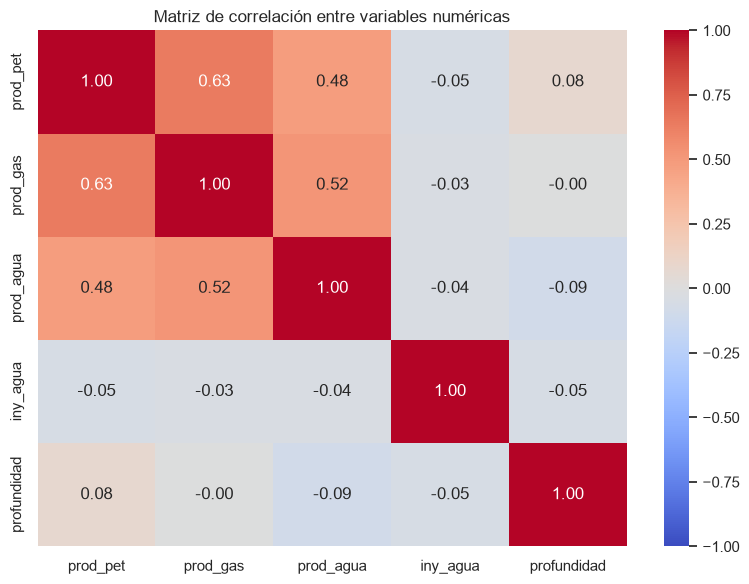

In [58]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

In [59]:
df_produccion_activa = df_cuyana[
    (df_cuyana["prod_pet"] > 0) |
    (df_cuyana["prod_gas"] > 0) |
    (df_cuyana["prod_agua"] > 0)
].copy()

matriz_corr_activa = (
    df_produccion_activa[variables_correlacion]
    .corr(method="pearson")
)

matriz_corr_activa

,prod_pet,prod_gas,prod_agua,iny_agua,profundidad
prod_pet,1.000000,0.480888,0.196838,-0.005172,0.096075
prod_gas,0.480888,1.000000,0.361397,-0.002946,-0.090163
prod_agua,0.196838,0.361397,1.000000,-0.003351,-0.331281
iny_agua,-0.005172,-0.002946,-0.003351,1.000000,-0.002842
profundidad,0.096075,-0.090163,-0.331281,-0.002842,1.000000


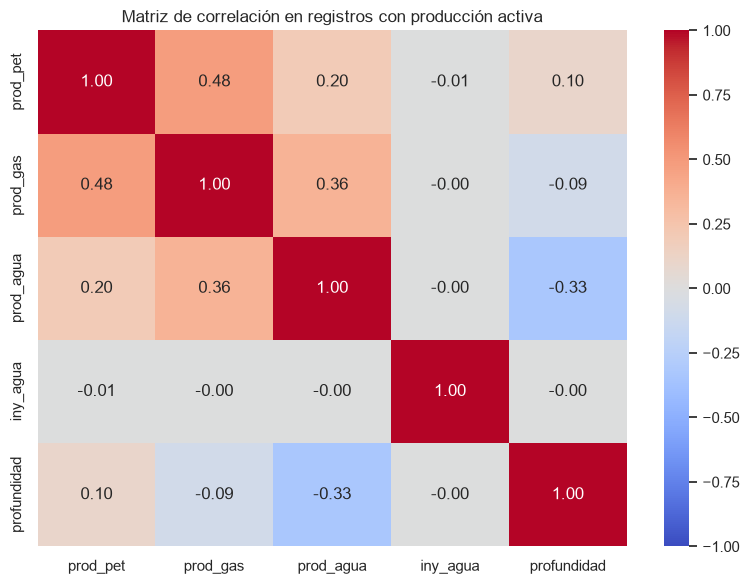

In [60]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_corr_activa,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlación en registros con producción activa")
plt.tight_layout()
plt.show()

### 15.2 Interpretación de la matriz de correlación

La matriz calculada sobre el dataset completo muestra asociaciones positivas moderadas entre las variables de producción. La relación más elevada se observa entre `prod_pet` y `prod_gas`, seguida por `prod_gas` y `prod_agua`, y por `prod_pet` y `prod_agua`.

Sin embargo, al repetir el análisis únicamente sobre registros con alguna producción positiva, estas correlaciones disminuyen. Esto sugiere que la elevada presencia de registros con producción simultáneamente igual a cero influye en las correlaciones observadas sobre el conjunto completo.

En los registros con actividad productiva, la asociación entre petróleo y gas continúa siendo positiva, aunque de intensidad moderada. Las relaciones entre producción e `iny_agua` son prácticamente nulas.

La variable `profundidad` presenta correlaciones débiles con la mayoría de las variables. Se observa una asociación negativa de aproximadamente -0,33 entre profundidad y producción de agua en los registros activos, que se considera un hallazgo exploratorio y requiere análisis adicional antes de extraer conclusiones.

Estas correlaciones representan asociaciones lineales y no implican relaciones causales.

### 15.3 Efecto de los períodos sin producción sobre las correlaciones

La comparación entre ambas matrices muestra que los períodos con producción simultáneamente igual a cero pueden influir en la magnitud de algunas correlaciones entre las variables de producción.

Al considerar únicamente registros con alguna producción positiva, varias asociaciones disminuyen, lo que indica que los períodos sin actividad productiva afectan la estructura de correlación observada en el conjunto completo.

Por este motivo, para interpretar relaciones asociadas al comportamiento productivo se considera más informativa la matriz calculada sobre registros con actividad, mientras que la matriz completa se conserva como descripción del conjunto total de datos.

### 15.4 Relación preliminar con `meses_hasta_pico`

Esta parte queda pendiente hasta que se construya la variable `meses_hasta_pico` en la etapa de Feature Engineering.

Una vez disponible, se explorará su relación con variables categóricas como operador y yacimiento, con el objetivo de identificar patrones preliminares que luego deberán validarse en etapas posteriores.

## 16. Notebook final de EDA / conclusiones